# Exploratory Data Analysis

Understanding feature distributions, mood correlations, and potential class separability before training. Key questions: 
- Are features actually predictive of mood?
- Do any moods overlap heavily (hard to separate)?
- Is 'food_eaten' or 'activity' the dominant signal?

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.preprocess import load_and_clean, CATEGORICAL_COLS, NUMERIC_COLS

sns.set_theme(style="whitegrid", palette="muted")
df = load_and_clean(path="../data/raw/cat_behavior_synthetic.csv")

print(f"Shape: {df.shape}")
print(f"Nulls: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
df.head()

Shape: (1996, 6)
Nulls: 0
Duplicates: 0


,time_of_day,activity,tail_position,ear_direction,food_eaten,mood
0,16.7,1.0,4.0,2.0,0.94,happy
1,3.1,2.0,0.0,1.0,0.24,grumpy
2,19.7,5.0,0.0,0.0,0.66,sleepy
3,1.5,5.0,0.0,0.0,0.62,sleepy
4,23.3,1.0,0.0,0.0,0.54,sleepy


## Numeric Feature Distributions by Mood

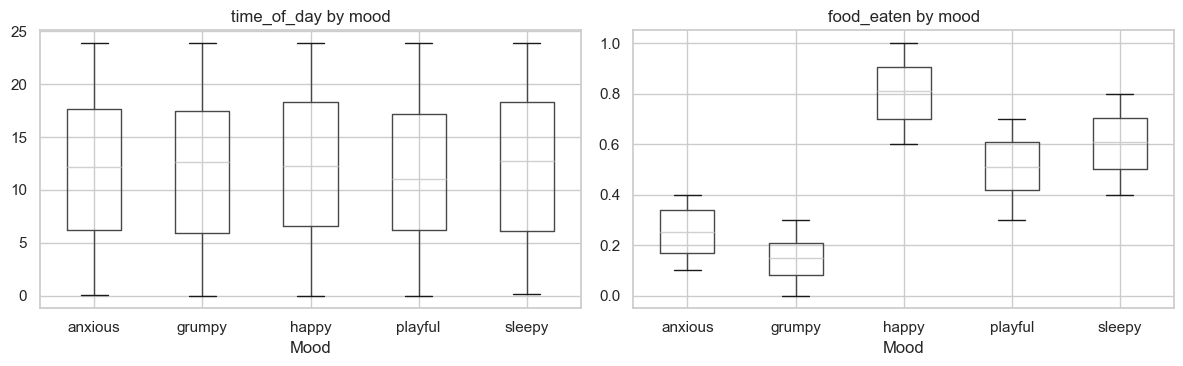

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, NUMERIC_COLS):
    df.boxplot(column=col, by="mood", ax=ax)
    ax.set_title(f"{col} by mood")
    ax.set_xlabel("Mood")

plt.suptitle("")
plt.tight_layout()

## Categorical Feature Frequencies by Mood

How often does each activity / tail position / ear direction appear per mood?
Stacked bars make overlap between moods visible.

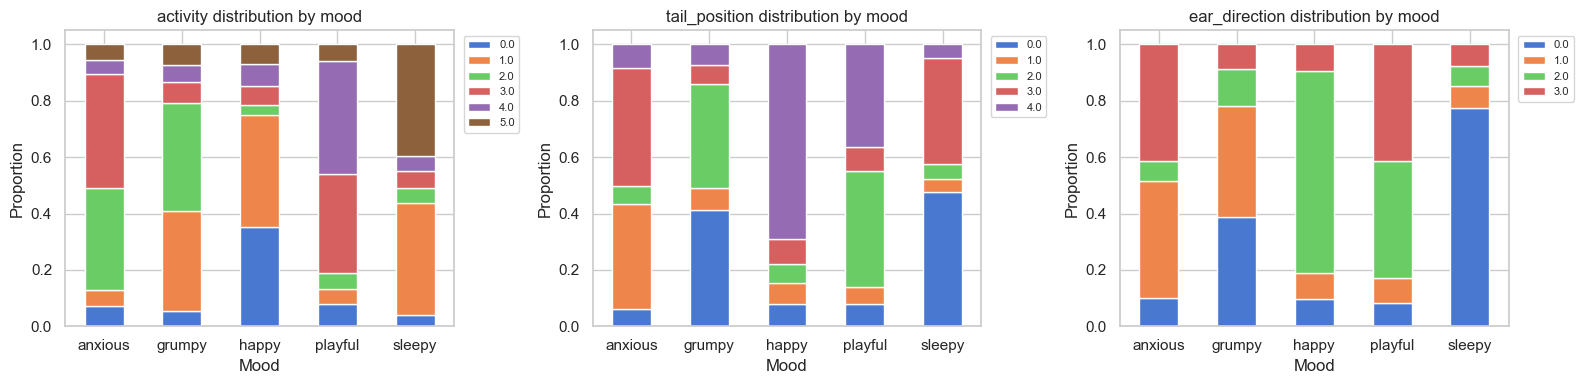

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, CATEGORICAL_COLS):
    ct = pd.crosstab(df["mood"], df[col], normalize="index")
    ct.plot.bar(stacked=True, ax=ax, legend=True)
    ax.set_title(f"{col} distribution by mood")
    ax.set_xlabel("Mood")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

    plt.tight_layout()

## food_eaten vs time_of_day by Mood

Scatter plot to check whether the two numeric features together create separable clusters per mood.

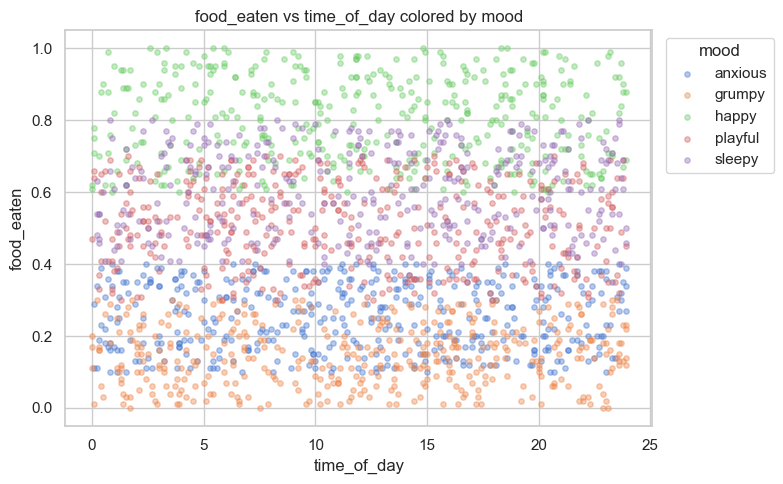

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
moods = df["mood"].unique()
colors = sns.color_palette("muted", len(moods))

for mood, color in zip(sorted(moods), colors):
    subset = df[df["mood"] == mood]
    ax.scatter(subset["time_of_day"], subset["food_eaten"], 
               label=mood, alpha=0.4, s=15, color=color)

ax.set_xlabel("time_of_day")
ax.set_ylabel("food_eaten")
ax.set_title("food_eaten vs time_of_day colored by mood")
ax.legend(title="mood", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()

## Correlation Heatmap (Encoded Features)

Ordinal-encode categoricals to get a numeric correlation matrix. 
This shows which features move together and which are independent.

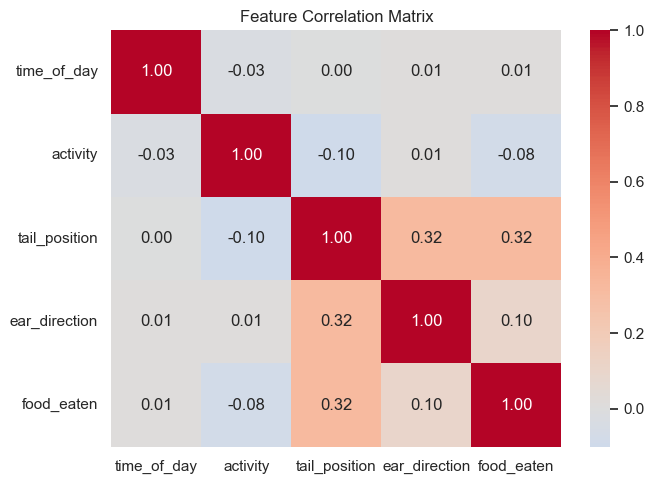

In [5]:
from sklearn.preprocessing import OrdinalEncoder

df_enc = df.copy()
df_enc[CATEGORICAL_COLS] = OrdinalEncoder().fit_transform(df_enc[CATEGORICAL_COLS])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df_enc.drop(columns=["mood"]).corr().round(2), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()

## Mean Feature Values per Mood

Quick summary table - which moods have the highest food consumption, latest activity times, etc.

In [6]:
df_enc2 = df.copy()
df_enc2[CATEGORICAL_COLS] = OrdinalEncoder().fit_transform(df_enc2[CATEGORICAL_COLS])

df_enc2.groupby("mood")[NUMERIC_COLS + CATEGORICAL_COLS].mean().round(3).sort_index()

,time_of_day,food_eaten,activity,tail_position,ear_direction
mood,,,,,
anxious,12.032,0.254,2.471,2.089,1.798
grumpy,12.086,0.147,1.951,1.313,0.914
happy,12.321,0.803,1.329,3.238,1.808
playful,11.576,0.510,3.120,2.592,2.158
sleepy,12.434,0.603,2.876,1.473,0.448


## Key Findings

### Feature Predictiveness
| Feature | Predictiveness | Observation |
|---|---|---|
| 'food_eaten' | **High** | Cleanest separator - clear ordering: 'grumpy' (0.147) → 'anxious' (0.254) → 'playful' (0.510) → 'sleepy' (0.603) → 'happy' (0.803). Non-overlapping IQRs in box plot. |
| 'activity' | **High** | Encoded means range from 1.329 ('happy') to 3.120 ('playful') - distinct profiles per mood in stacked bars |
| 'tail_position' | **Medium** | Separates 'happy' (high encoded mean 3.238) from 'grumpy' (1.313) well, but 'anxious'/'sleepy' overlap |
| 'ear_direction' | **Medium** | 'sleepy' is strongly dominant at 0.448 (backward ears), but 'happy' and 'anxious' share similar vales (-1.8) |
| 'time_of_day' | **None** | All mood medians sit at ~12.0 with identical IQRs. Scatter plot shows zero horizontal structure - pure noise. |

### Mood Separability
- **Easiest to classify:** 'happy' - uniquely high 'food_eaten', distinct tail and activity profile
- **Easiest to classify:** 'sleepy' - lowest 'ear_direction' score (backward ears), distinct activity
- **Hardest to classify** 'grumpy' vs 'anxious' - 'food_eaten' means are closest (0.147 vs 0.254), overlapping food ranges visible in box plot, and both share low-encoded activity and tail values. This pair is the primary source of the ~16% error rate.

### Correlation Structure
- 'tail_position' ↔ 'ear_direction': 0.32 - moderate co-variance, expected since 'MOOD_RULES' ties both features to the same moods
- 'tail_position' ↔ 'food_eaten': 0.32 - happy cats (high food) also have  tails up
- All other pairs near 0 - features are largely independent, which benefits both RF and LR
- 'time_of_day' correlates at ≤ 0.03 with everything - confirms it contributes no signal

### Scatter Plot
- 'food_eaten' creates clear horizontal bands: 'happy' clusters 0.6-1.0, 'grumpy' 0.0-0.3
- No vertical structure at any 'time_od_day' value - confirms it should be dropped or deprioritized in feature selection experiments in Week 3

### Chart Note
The stacked bar legends display encoded integers (0.0-0.5) instead of category names because 'OrdinalEncoder' was applied before 'pd.crosstab'. The relative proportions are still valid - label mapping can be verified against 'generate_synthetic.py' constants if needed. 

### Data Quality
- 0 nulls, 0 duplicates post-cleaning
- All numeric values within expected bounds
- Class balance is uniform (~400 per mood) - no resampling needed


In [7]:
import os
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("data/processed/cat_behavior_clean.csv", index=False)
print(f"Saved cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Saved cleaned dataset: 1996 rows, 6 columns
